In [86]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_sample_weight
from statsmodels.miscmodels.ordinal_model import OrderedModel

data_path = "/home/dsemchin/data/data_ppmi_pd_with_best_model_subject_cols.csv"
time_col = "time"

data_path = "/home/dsemchin/data/data_ppmi_pd_with_best_model_subject_cols.csv"
df_all = pd.read_csv(data_path)

# one row per subject (final visit)
final_idx = df_all.groupby("subj_id")[time_col].idxmax()
subj_df = df_all.loc[final_idx].copy()

subj_df["NSD_STAGE"] = pd.to_numeric(subj_df["NSD_STAGE"], errors="coerce")
subj_df.loc[subj_df["NSD_STAGE"] == 0, "NSD_STAGE"] = np.nan

cat_levels = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
subj_df["NSD_ordered"] = pd.Categorical(subj_df["NSD_STAGE"], categories=cat_levels, ordered=True)

cols_needed = ["NSD_ordered", "MCATOT", "TD_score", "PIGD_score", "model_split_best"]
model_df = subj_df.dropna(subset=cols_needed).copy()

ord_train = model_df[model_df["model_split_best"] == "train"].copy()
ord_val = model_df[model_df["model_split_best"] == "val"].copy()

ord_train["NSD_ordered"] = ord_train["NSD_ordered"].cat.remove_unused_categories()
ord_val["NSD_ordered"] = ord_val["NSD_ordered"].cat.remove_unused_categories()

# same category order in both splits (use full scale from training fit)
full_cats = ord_train["NSD_ordered"].cat.categories
ord_val["NSD_ordered"] = pd.Categorical(
    ord_val["NSD_ordered"].astype(float), categories=full_cats, ordered=True
)

print("\nRows by model_split_best:")
print(df_all["model_split_best"].value_counts(dropna=False))
print("\nUnique subjects by model_split_best:")
print(df_all.groupby("model_split_best")["subj_id"].nunique())
print("\nPatients with NSD stage (complete cases):")
print("Train n:", len(ord_train), "| Val n:", len(ord_val))
print("Train NSD counts:\n", ord_train["NSD_ordered"].value_counts().sort_index())
print("Val NSD counts:\n", ord_val["NSD_ordered"].value_counts().sort_index())


Rows by model_split_best:
model_split_best
train       513
not_used    235
val         132
Name: count, dtype: int64

Unique subjects by model_split_best:
model_split_best
not_used    231
train       116
val          30
Name: subj_id, dtype: int64

Patients with NSD stage (complete cases):
Train n: 98 | Val n: 25
Train NSD counts:
 NSD_ordered
3.0    67
4.0    28
5.0     2
6.0     1
Name: count, dtype: int64
Val NSD counts:
 NSD_ordered
3.0    17
4.0     6
5.0     2
6.0     0
Name: count, dtype: int64


In [87]:
print(df_all["subtype_best"].value_counts(dropna=True))

subtype_best
0.0    330
1.0    224
2.0     91
Name: count, dtype: int64


In [88]:
class WeightedOrderedModel(OrderedModel):
    def __init__(self, endog, exog, sample_weights=None, distr="logit", **kwargs):
        super().__init__(endog, exog, distr=distr, **kwargs)
        if sample_weights is None:
            sample_weights = np.ones(self.nobs)
        w = np.asarray(sample_weights, dtype=float)
        self.sample_weights = w * (self.nobs / w.sum())

    def loglikeobs(self, params):
        return self.sample_weights * super().loglikeobs(params)

    def score_obs(self, params):
        return self.sample_weights[:, None] * super().score_obs(params)

## Ord regression clinical scores only

                          WeightedOrderedModel Results                          
Dep. Variable:              NSD_ordered   Log-Likelihood:                -84.721
Model:             WeightedOrderedModel   AIC:                             181.4
Method:              Maximum Likelihood   BIC:                             197.0
Date:                  Mon, 27 Apr 2026                                         
Time:                          17:33:33                                         
No. Observations:                    98                                         
Df Residuals:                        92                                         
Df Model:                             3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
MCATOT        -0.6448      2.032     -0.317      0.751      -4.628       3.339
TD_score      -0.0814      0.718  

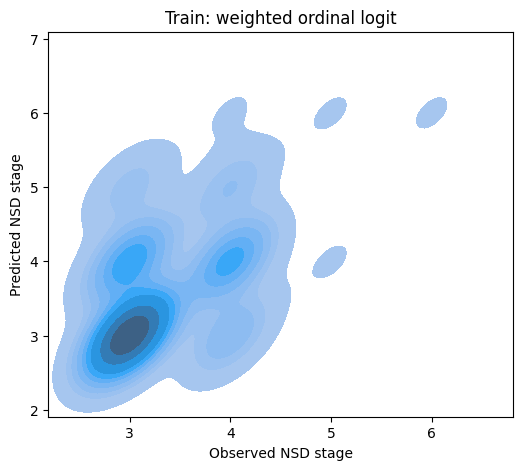

Train accuracy: 0.6429


In [89]:
y_train = ord_train["NSD_ordered"]
X_train = ord_train[["MCATOT", "TD_score", "PIGD_score"]]
w_train = compute_sample_weight(class_weight="balanced", y=y_train)

mod_train = WeightedOrderedModel(y_train, X_train, sample_weights=w_train, distr="logit")
res_train = mod_train.fit(method="bfgs", disp=False, cov_type="HC1")
print(res_train.summary())

pred_probas_train = res_train.model.predict(params=res_train.params, exog=X_train)
pred_idx_train = np.argmax(pred_probas_train, axis=1)
pred_cat_train = pd.Series(full_cats[pred_idx_train], index=y_train.index).astype(float)
true_cat_train = y_train.astype(float)

plt.figure(figsize=(6, 5))
sns.kdeplot(x=true_cat_train, y=pred_cat_train, fill=True)
plt.xlabel("Observed NSD stage")
plt.ylabel("Predicted NSD stage")
plt.title("Train: weighted ordinal logit")
plt.show()
print(f"Train accuracy: {np.mean(pred_cat_train.values == true_cat_train.values):.4f}")


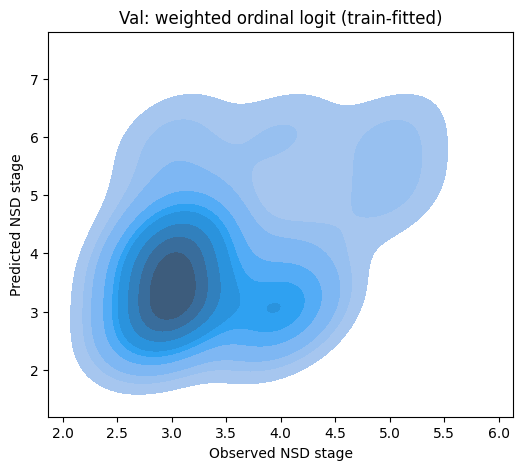

Val accuracy: 0.4000


In [90]:

y_val = ord_val["NSD_ordered"]
X_val = ord_val[["MCATOT", "TD_score", "PIGD_score"]]
pred_probas_val = res_train.model.predict(params=res_train.params, exog=X_val)
pred_idx_val = np.argmax(pred_probas_val, axis=1)
pred_cat_val = pd.Series(full_cats[pred_idx_val], index=y_val.index).astype(float)
true_cat_val = y_val.astype(float)

plt.figure(figsize=(6, 5))
sns.kdeplot(x=true_cat_val, y=pred_cat_val, fill=True)
plt.xlabel("Observed NSD stage")
plt.ylabel("Predicted NSD stage")
plt.title("Val: weighted ordinal logit (train-fitted)")
plt.show()
print(f"Val accuracy: {np.mean(pred_cat_val.values == true_cat_val.values):.4f}")

In [91]:
from sklearn.metrics import f1_score

# train (use your pred_cat_train / true_cat_train)
f1_train = f1_score(
    true_cat_train,
    pred_cat_train,
    average="weighted",
    labels=full_cats.astype(float),  # or list(full_cats); keeps class order stable
    zero_division=0,
)

# val
f1_val = f1_score(
    true_cat_val,
    pred_cat_val,
    average="weighted",
    labels=full_cats.astype(float),
    zero_division=0,
)


print(f1_train)
print(f1_val)

0.6790774160904031
0.44945812807881774


### ord regression with subtype

In [92]:
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_sample_weight

SUBTYPE = [0, 1, 2]
clin_cols = ["MCATOT", "TD_score", "PIGD_score"]

sub_train = pd.Series(
    pd.Categorical(ord_train["subtype_best"].astype(int), categories=SUBTYPE),
    index=ord_train.index,
)
subtype_dummies = pd.get_dummies(
    sub_train, prefix="subtype", prefix_sep="_", drop_first=True
).astype(int)
X_train_sub = pd.concat([ord_train[clin_cols], subtype_dummies], axis=1)

w_train = compute_sample_weight(class_weight="balanced", y=ord_train["NSD_ordered"])
mod_sub = WeightedOrderedModel(
    ord_train["NSD_ordered"], X_train_sub, sample_weights=w_train, distr="logit"
)
res_sub = mod_sub.fit(method="bfgs", disp=False, cov_type="HC1")
print(res_sub.summary())

sub_val = pd.Series(
    pd.Categorical(ord_val["subtype_best"].astype(int), categories=SUBTYPE),
    index=ord_val.index,
)
subtype_dummies_val = pd.get_dummies(
    sub_val, prefix="subtype", prefix_sep="_", drop_first=True
).astype(int)
subtype_dummies_val = subtype_dummies_val.reindex(
    columns=subtype_dummies.columns, fill_value=0
)
X_val_sub = pd.concat([ord_val[clin_cols], subtype_dummies_val], axis=1)


                          WeightedOrderedModel Results                          
Dep. Variable:              NSD_ordered   Log-Likelihood:                -80.076
Model:             WeightedOrderedModel   AIC:                             176.2
Method:              Maximum Likelihood   BIC:                             196.8
Date:                  Mon, 27 Apr 2026                                         
Time:                          17:33:34                                         
No. Observations:                    98                                         
Df Residuals:                        90                                         
Df Model:                             5                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
MCATOT        -0.6517      1.915     -0.340      0.734      -4.404       3.101
TD_score      -0.0732      0.335  

In [93]:
pred_probas_train = res_sub.model.predict(params=res_sub.params, exog=X_train_sub)
pred_idx_train = np.argmax(pred_probas_train, axis=1)
pred_cat_train = pd.Series(
    full_cats[pred_idx_train], index=ord_train["NSD_ordered"].index
).astype(float)
true_cat_train = ord_train["NSD_ordered"].astype(float)
print(f"Train accuracy: {np.mean(pred_cat_train.values == true_cat_train.values):.4f}")

pred_probas_val = res_sub.model.predict(params=res_sub.params, exog=X_val_sub)
pred_idx_val = np.argmax(pred_probas_val, axis=1)
pred_cat_val = pd.Series(
    full_cats[pred_idx_val], index=ord_val["NSD_ordered"].index
).astype(float)
true_cat_val = ord_val["NSD_ordered"].astype(float)
print(f"Val accuracy: {np.mean(pred_cat_val.values == true_cat_val.values):.4f}")

Train accuracy: 0.5714
Val accuracy: 0.4000


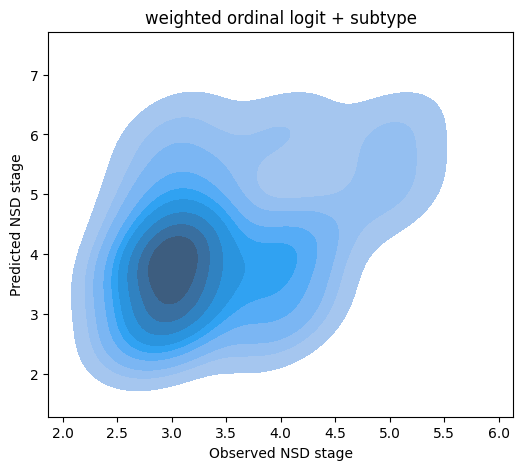

Val accuracy: 0.4000


In [94]:
plt.figure(figsize=(6, 5))
sns.kdeplot(x=true_cat_val, y=pred_cat_val, fill=True)
plt.xlabel("Observed NSD stage")
plt.ylabel("Predicted NSD stage")
plt.title("weighted ordinal logit + subtype")
plt.show()
print(f"Val accuracy: {np.mean(pred_cat_val.values == true_cat_val.values):.4f}")

In [95]:
from sklearn.metrics import f1_score

# train (use your pred_cat_train / true_cat_train)
f1_train = f1_score(
    true_cat_train,
    pred_cat_train,
    average="weighted",
    labels=full_cats.astype(float),  # or list(full_cats); keeps class order stable
    zero_division=0,
)

# val
f1_val = f1_score(
    true_cat_val,
    pred_cat_val,
    average="weighted",
    labels=full_cats.astype(float),
    zero_division=0,
)


print(f1_train)
print(f1_val)

0.6110544217687075
0.4431058823529412


In [ ]:
"""
Continuation-ratio / discrete-time survival ordinal regression for
longitudinal panel data, with sklearn-compatible API.
"""

from __future__ import annotations

import inspect
from typing import Optional, Sequence, Union

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import AdaBoostRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.utils.validation import check_is_fitted


class AdaBoostBinaryRegressor(BaseEstimator):
    """
    AdaBoost.R2 regressor wrapped to expose a binary-classifier-like
    predict_proba interface for use as a base hazard model.

    Fits an AdaBoostRegressor (Drucker 1997) on a {0, 1} target, treats
    the regression output as P(y=1 | x), and clips to (eps, 1-eps) to
    avoid degenerate logits during downstream calibration.

    Parameters mirror sklearn's AdaBoostRegressor; default loss='square'
    targets the conditional mean (a probability for 0/1 targets), unlike
    the package default 'linear' which targets the conditional median.
    """

    def __init__(
        self,
        estimator=None,
        n_estimators: int = 50,
        learning_rate: float = 1.0,
        loss: str = "square",
        random_state=None,
        eps: float = 1e-6,
    ):
        self.estimator = estimator
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.loss = loss
        self.random_state = random_state
        self.eps = eps

    def fit(self, X, y, sample_weight=None):
        y = np.asarray(y).astype(float)
        unique = np.unique(y)
        if not set(unique.tolist()).issubset({0.0, 1.0}):
            raise ValueError(
                f"AdaBoostBinaryRegressor expects binary {{0, 1}} targets; got {unique}"
            )
        self.regressor_ = AdaBoostRegressor(
            estimator=self.estimator,
            n_estimators=self.n_estimators,
            learning_rate=self.learning_rate,
            loss=self.loss,
            random_state=self.random_state,
        )
        self.regressor_.fit(X, y, sample_weight=sample_weight)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        check_is_fitted(self, "regressor_")
        p1 = np.clip(self.regressor_.predict(X), self.eps, 1.0 - self.eps)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


class OrdinalDiscreteTimeSurvival(BaseEstimator, ClassifierMixin):
    """
    Continuation-ratio / discrete-time survival ordinal classifier for
    longitudinal panel data.

    For an ordered target with classes c_1 < c_2 < ... < c_K, fits K-1
    independent binary "hazard" models, one per threshold. For threshold
    k (separating c_k from c_{k+1}), the model estimates

        h_k(j; x) = P(Y_{i,j} >= c_{k+1} | not-yet-crossed, x_{i,j})

    on the at-risk subset (subjects who have not yet crossed k) at each
    visit j. Subjects are right-censored at their last observed visit if
    they never cross.

    At prediction time, hazards are accumulated within subject in time
    order to give monotone (in visit) cumulative threshold-crossing
    probabilities

        F_k(j) = 1 - prod_{j' <= j} (1 - h_k(j'; x_{j'}))

    from which per-class probabilities at each visit are derived via the
    continuation-ratio identity.

    Parameters
    ----------
    order : array-like, optional
        Expected ordered class values, lowest to highest. REQUIRED if y
        is non-numeric. If y is numeric and `order` is None, classes are
        taken as np.unique(y) sorted ascending. Raises if y contains any
        value not in `order`.

    base_estimator : sklearn classifier, optional
        Binary classifier with `predict_proba`. One clone is fitted per
        threshold. Default: AdaBoostBinaryRegressor (AdaBoost.R2 with
        square loss, wrapped to expose predict_proba).

    subj_id_col, time_col : str
        Names of the subject-id and within-subject relative-time columns
        in X. Time values are used only to ORDER visits within a subject;
        their numeric values are not used as covariates.

    include_visit_index : bool, default=True
        Include the within-subject visit number (1, 2, ...) as a feature
        of each hazard model — represents the discrete-time baseline
        hazard.

    class_weight : {'balanced', None}, default='balanced'
        If 'balanced', applies inverse-frequency sample weights to each
        threshold's binary problem (computed within that threshold's
        at-risk set).

    enforce_threshold_ordering : bool, default=True
        At prediction time, enforce P(Y >= c_{k+1}) >= P(Y >= c_{k+2})
        by post-hoc cumulative max from the highest threshold downward.
        Without this, threshold-specific (non-PO) hazards may produce
        internally inconsistent stage probabilities.

    calibration_method : {'platt', 'prior', None}, default='platt'
        Per-threshold probability calibration applied at predict time.

        - 'platt': Held-out Platt scaling. At fit time, a fraction of
          subjects (`calibration_fraction`) is held out from base-model
          fitting; the base predictions on that held-out set are mapped
          to calibrated probabilities via a 1-D logistic regression
              P(y=1 | p_raw) = sigmoid(a * logit(p_raw) + b)
          fit per threshold. Works for any base estimator and absorbs the
          intercept shift from class_weight='balanced' automatically.

        - 'prior': Closed-form intercept correction for the bias from
          class_weight='balanced'. Stores per-threshold crossing rate
          pi_k on the at-risk training set; at predict time subtracts
          log((1 - pi_k) / pi_k) from the predicted hazard logit. EXACT
          for LogisticRegression, APPROXIMATE for nonlinear estimators.

        - None: no calibration; raw base-estimator probabilities are
          used. Predictions will be biased upward when class_weight
          ='balanced' was used at fit time.

    calibration_fraction : float, default=0.25
        Fraction of training subjects held out for Platt calibration.
        Ignored unless calibration_method='platt'. Subject-level split
        (not row-level) to avoid leakage of within-subject correlation.

    calibration_random_state : int or None, default=None
        Seed for the subject-level calibration split. Set for
        reproducibility.

    Attributes
    ----------
    classes_ : np.ndarray, shape (K,)
        Ordered class labels (output order of `predict_proba`).
    threshold_models_ : dict[int, estimator or tuple]
        Fitted estimator for threshold k, or a ('constant', value) pair
        if the at-risk set was degenerate (single class or empty).
    platt_models_ : dict[int, LogisticRegression or None]
        Per-threshold Platt-scaling logistic regressions; None if a
        threshold's calibration set was too sparse (single-class, empty,
        or fewer than 10 at-risk rows).
    priors_ : dict[int, float]
        Per-threshold event rate pi_k on the at-risk training set, used
        for 'prior' calibration and as a fallback when Platt cannot be fit.
    feature_names_ : list[str]
        Feature columns used by the hazard models, in order.
    K_ : int
        Number of classes.

    Notes
    -----
    Population-averaged model — does not estimate subject random effects.
    Cross-validate by SUBJECT (not by row) to avoid leakage.

    Per-visit reversals (Y going down then up due to noise) are handled
    by training on the FIRST-CROSSING time per (subject, threshold). Strict
    within-subject monotonicity is not required of the input, but the
    discrete-time survival interpretation assumes the underlying process
    is approximately monotone.
    """

    def __init__(
        self,
        order: Optional[Sequence] = None,
        base_estimator=None,
        subj_id_col: str = "subj_id",
        time_col: str = "time",
        include_visit_index: bool = True,
        class_weight: Optional[str] = "balanced",
        enforce_threshold_ordering: bool = True,
        calibration_method: Optional[str] = "platt",
        calibration_fraction: float = 0.25,
        calibration_random_state: Optional[int] = None,
    ):
        self.order = order
        self.base_estimator = base_estimator
        self.subj_id_col = subj_id_col
        self.time_col = time_col
        self.include_visit_index = include_visit_index
        self.class_weight = class_weight
        self.enforce_threshold_ordering = enforce_threshold_ordering
        self.calibration_method = calibration_method
        self.calibration_fraction = calibration_fraction
        self.calibration_random_state = calibration_random_state

    # ---------------- internal helpers ----------------

    def _validate_classes(self, y: np.ndarray) -> np.ndarray:
        observed = pd.unique(y)
        if self.order is None:
            if not np.issubdtype(np.asarray(y).dtype, np.number):
                raise ValueError(
                    f"y has non-numeric dtype {np.asarray(y).dtype}; "
                    "non-numeric targets require an explicit `order=` argument."
                )
            return np.sort(observed)

        order_arr = np.asarray(self.order)
        if len(set(order_arr.tolist())) != len(order_arr):
            raise ValueError("`order` contains duplicate values.")
        extras = pd.Index(observed).difference(pd.Index(order_arr)).tolist()
        if extras:
            raise ValueError(
                f"y contains values not in `order`: {extras}. "
                f"Provided order: {list(order_arr)}"
            )
        return order_arr

    def _split_panel(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "X must be a pandas DataFrame containing "
                f"`{self.subj_id_col}` and `{self.time_col}` columns."
            )
        for col in (self.subj_id_col, self.time_col):
            if col not in X.columns:
                raise ValueError(f"Required column `{col}` missing from X.")
        subj = X[self.subj_id_col].to_numpy()
        time = X[self.time_col].to_numpy()
        feats = X.drop(columns=[self.subj_id_col, self.time_col])
        if y is None:
            return feats, subj, time
        y_arr = np.asarray(y)
        if len(y_arr) != len(X):
            raise ValueError(f"len(y) {len(y_arr)} != len(X) {len(X)}.")
        return feats, subj, time, y_arr

    @staticmethod
    def _within_subject_visit_index(subj_sorted: np.ndarray) -> np.ndarray:
        """1-indexed visit number within each subject, assuming input is
        already sorted by (subject, time)."""
        s = pd.Series(subj_sorted)
        return s.groupby(s, sort=False).cumcount().to_numpy() + 1

    @staticmethod
    def _sort_by_subject_time(subj: np.ndarray, time: np.ndarray) -> np.ndarray:
        # Stable sort: primary key subject, secondary key time.
        df = pd.DataFrame({"_s": subj, "_t": time})
        return df.sort_values(["_s", "_t"], kind="mergesort").index.to_numpy()

    @staticmethod
    def _logit(p: np.ndarray, eps: float = 1e-12) -> np.ndarray:
        p = np.clip(p, eps, 1.0 - eps)
        return np.log(p / (1.0 - p))

    @staticmethod
    def _fit_platt(p_raw: np.ndarray, y: np.ndarray, min_n: int = 10):
        """Fit 1-D Platt scaling sigmoid(a * logit(p_raw) + b).

        Returns (a, b) or None if calibration set is too sparse / degenerate.
        Uses essentially unregularized logistic regression on the logit.
        Class balance inside Platt is left at NATURAL frequencies — Platt's
        job is to recover marginal calibration.
        """
        if len(y) < min_n or len(np.unique(y)) < 2:
            return None
        z = OrdinalDiscreteTimeSurvival._logit(p_raw).reshape(-1, 1)
        lr = LogisticRegression(C=1e12, max_iter=1000, solver="lbfgs")
        lr.fit(z, y)
        return float(lr.coef_[0, 0]), float(lr.intercept_[0])

    @staticmethod
    def _apply_platt(p_raw: np.ndarray, ab) -> np.ndarray:
        a, b = ab
        z = OrdinalDiscreteTimeSurvival._logit(p_raw)
        return 1.0 / (1.0 + np.exp(-(a * z + b)))

    # ---------------- fit ----------------

    def fit(self, X: pd.DataFrame, y):
        # Validate calibration_method
        if self.calibration_method not in (None, "platt", "prior"):
            raise ValueError(
                f"calibration_method must be one of None, 'platt', 'prior'; "
                f"got {self.calibration_method!r}."
            )
        if self.calibration_method == "platt" and not (
            0.0 < self.calibration_fraction < 1.0
        ):
            raise ValueError(
                f"calibration_fraction must be in (0, 1); "
                f"got {self.calibration_fraction!r}."
            )

        classes = self._validate_classes(np.asarray(y))
        self.classes_ = classes
        self.K_ = len(classes)
        if self.K_ < 2:
            raise ValueError(f"Need at least 2 classes; got {self.K_}.")
        rank_map = {c: i for i, c in enumerate(classes)}

        feats, subj, time, y_arr = self._split_panel(X, y)
        y_rank = np.array([rank_map[v] for v in y_arr], dtype=int)

        # Sort everything by (subject, time)
        order_idx = self._sort_by_subject_time(subj, time)
        feats_s = feats.iloc[order_idx].reset_index(drop=True)
        subj_s = subj[order_idx]
        y_rank_s = y_rank[order_idx]

        if self.include_visit_index:
            feats_s = feats_s.copy()
            feats_s["__visit_index__"] = self._within_subject_visit_index(subj_s)
        self.feature_names_ = list(feats_s.columns)

        # ---- subject-level split for Platt calibration ----
        unique_subj = pd.unique(subj_s)
        if self.calibration_method == "platt":
            rng = np.random.default_rng(self.calibration_random_state)
            shuffled = unique_subj.copy()
            rng.shuffle(shuffled)
            n_cal = max(1, int(round(self.calibration_fraction * len(shuffled))))
            if n_cal >= len(shuffled):
                raise ValueError(
                    f"calibration_fraction {self.calibration_fraction} leaves no "
                    f"subjects for base-model fitting (n_subjects={len(shuffled)})."
                )
            cal_subjects = set(shuffled[:n_cal].tolist())
            is_cal = np.array([s in cal_subjects for s in subj_s])
        else:
            is_cal = np.zeros(len(subj_s), dtype=bool)
        is_base_fit = ~is_cal

        base = (
            self.base_estimator
            if self.base_estimator is not None
            else AdaBoostBinaryRegressor()
        )
        if not hasattr(base, "predict_proba"):
            raise TypeError(
                f"base_estimator {type(base).__name__} must implement predict_proba."
            )
        supports_sw = "sample_weight" in inspect.signature(base.fit).parameters

        df_subj = pd.Series(subj_s)
        Xv = feats_s.to_numpy()
        self.threshold_models_ = {}
        self.platt_models_ = {}
        self.priors_ = {}  # per-threshold event rate, used by 'prior' method / fallback

        for k in range(self.K_ - 1):
            crossed = (y_rank_s > k).astype(int)
            cs = pd.Series(crossed).groupby(df_subj, sort=False).cumsum().to_numpy()
            cs_before = cs - crossed
            at_risk = cs_before == 0  # not yet crossed coming into this visit

            if not at_risk.any():
                self.threshold_models_[k] = ("constant", 0.0)
                self.platt_models_[k] = None
                self.priors_[k] = 0.0
                continue

            # split at-risk rows by base-fit / calibration subject membership
            base_mask = at_risk & is_base_fit
            cal_mask = at_risk & is_cal
            X_k = Xv[base_mask]
            y_k = crossed[base_mask]

            # Prior is computed on the BASE-FIT at-risk set (the set the base
            # model was actually trained on); this matches the data-generating
            # premise for the King–Zeng correction.
            self.priors_[k] = float(y_k.mean()) if len(y_k) > 0 else 0.0

            if len(y_k) == 0 or len(np.unique(y_k)) < 2:
                # Degenerate base-fit set for this threshold.
                const = float(y_k.mean()) if len(y_k) > 0 else 0.0
                self.threshold_models_[k] = ("constant", const)
                self.platt_models_[k] = None
                continue

            if self.class_weight == "balanced":
                sw = compute_sample_weight("balanced", y_k)
            elif self.class_weight is None:
                sw = None
            else:
                raise ValueError(
                    f"class_weight must be 'balanced' or None; got {self.class_weight!r}."
                )

            est = clone(base)
            if supports_sw:
                est.fit(X_k, y_k, sample_weight=sw)
            elif sw is not None:
                raise ValueError(
                    f"base_estimator {type(base).__name__} does not support "
                    "sample_weight; pass class_weight=None or use a different estimator."
                )
            else:
                est.fit(X_k, y_k)
            self.threshold_models_[k] = est

            # ---- Platt fit on held-out at-risk calibration rows ----
            if self.calibration_method == "platt" and cal_mask.any():
                X_cal_k = Xv[cal_mask]
                y_cal_k = crossed[cal_mask]
                p_raw = est.predict_proba(X_cal_k)[:, 1]
                self.platt_models_[k] = self._fit_platt(p_raw, y_cal_k)
            else:
                self.platt_models_[k] = None

        return self

    # ---------------- predict ----------------

    def _cumulative_crossing_probs(self, X: pd.DataFrame) -> np.ndarray:
        """Per-row F_k(visit) = P(Y_{ij} >= c_{k+1} | x_{i,1:j}) for k=0..K-2."""
        check_is_fitted(self)
        feats, subj, time = self._split_panel(X)
        order_idx = self._sort_by_subject_time(subj, time)
        feats_s = feats.iloc[order_idx].reset_index(drop=True)
        subj_s = subj[order_idx]

        if self.include_visit_index:
            feats_s = feats_s.copy()
            feats_s["__visit_index__"] = self._within_subject_visit_index(subj_s)

        missing = [c for c in self.feature_names_ if c not in feats_s.columns]
        if missing:
            raise ValueError(f"Features missing in X: {missing}")
        feats_s = feats_s[self.feature_names_]

        n = len(feats_s)
        Km1 = self.K_ - 1
        Xv = feats_s.to_numpy()

        hazards = np.zeros((n, Km1))
        for k in range(Km1):
            m = self.threshold_models_[k]
            if isinstance(m, tuple) and m[0] == "constant":
                hazards[:, k] = m[1]
                continue

            h = m.predict_proba(Xv)[:, 1]

            if self.calibration_method == "platt":
                ab = self.platt_models_.get(k)
                if ab is not None:
                    h = self._apply_platt(h, ab)
                else:
                    # Fallback: prior correction if balanced was used, else raw.
                    if self.class_weight == "balanced":
                        pi = self.priors_.get(k, 0.5)
                        if 0.0 < pi < 1.0:
                            h = 1.0 / (
                                1.0 + np.exp(
                                    -(self._logit(h) + np.log(pi / (1.0 - pi)))
                                )
                            )
            elif self.calibration_method == "prior":
                if self.class_weight == "balanced":
                    pi = self.priors_.get(k, 0.5)
                    if 0.0 < pi < 1.0:
                        h = 1.0 / (
                            1.0 + np.exp(
                                -(self._logit(h) + np.log(pi / (1.0 - pi)))
                            )
                        )
            # else: calibration_method is None; use raw h.

            hazards[:, k] = h

        # Cumulative threshold-crossing prob within subject:
        # F_k(j) = 1 - prod_{j'<=j} (1 - h_k(j')); compute via cumsum of log(1-h).
        log_surv = np.log(np.clip(1.0 - hazards, 1e-12, 1.0))
        cum = (
            pd.DataFrame(log_surv)
            .groupby(subj_s, sort=False)
            .cumsum()
            .to_numpy()
        )
        F = 1.0 - np.exp(cum)

        # Enforce P(Y >= c_{k+1}) >= P(Y >= c_{k+2}) (consistency across thresholds)
        if self.enforce_threshold_ordering and Km1 >= 2:
            for k in range(Km1 - 2, -1, -1):
                F[:, k] = np.maximum(F[:, k], F[:, k + 1])

        # Restore original input row order
        unsort = np.argsort(order_idx)
        return F[unsort]

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """
        P(Y_{i,j} = c_m | history up to visit j) for each row of X.

        Returns array of shape (n_rows, K) with columns in `self.classes_` order.
        Within-subject sequences are monotone in the cumulative sense
        (F_k(j) non-decreasing in j) by construction.
        """
        F = self._cumulative_crossing_probs(X)  # (n, K-1); F[:, k] = P(Y >= c_{k+1})
        n, Km1 = F.shape
        K = Km1 + 1
        proba = np.empty((n, K))
        proba[:, 0] = 1.0 - F[:, 0]
        for m in range(1, K - 1):
            proba[:, m] = F[:, m - 1] - F[:, m]
        proba[:, K - 1] = F[:, K - 2]
        # Numerical safety
        proba = np.clip(proba, 0.0, None)
        s = proba.sum(axis=1, keepdims=True)
        s[s == 0] = 1.0
        return proba / s

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """Modal stage prediction per row (label drawn from `self.classes_`)."""
        idx = np.argmax(self.predict_proba(X), axis=1)
        return np.asarray(self.classes_)[idx]

0.6790774160904031
0.44945812807881774